# 03 — Preprocessing

Deep-learning course project: **Citrus Leaf Disease Classification**
(`aphids`, `gummosis`, `healthy`, `leaf_minnor`)

This notebook builds the fixed image-processing pipeline that turns the raw,
full-resolution phone-camera photos referenced in `metadata_split.csv` into
two ready-to-train image sets (`224x224` and `128x128`), and computes the
per-channel normalization statistics for the training split.

**No pretrained models or transfer learning are used anywhere in this
notebook.** Every step below is classical image processing (OpenCV / NumPy
only) — there is no model of any kind in this notebook.

Pipeline, in order, for every image:
1. Load with OpenCV (BGR) -> convert to RGB.
2. Optional HSV-based leaf crop (falls back to the full frame when the
   detected leaf region is too small or segmentation fails).
3. Mild `cv2.medianBlur` (kernel size 3) to denoise without destroying the
   fine texture disease classification depends on.
4. Resize to `224x224` and `128x128` with `cv2.INTER_AREA` (correct for
   downsizing from these much larger originals).

Outputs are written to:
```
processed/224/<split>/<class_label>/<original_filename>
processed/128/<split>/<class_label>/<original_filename>
```

**Environment:** Windows, Python 3.13 venv. Only `numpy`, `pandas`,
`opencv-python-headless`, `pillow`, `scikit-learn`, `matplotlib`, `seaborn`,
`tqdm` are installed — this notebook only uses `numpy`, `pandas`, `opencv`
(`cv2`), `matplotlib`, and `tqdm` from that list, plus the standard library.
No GPU / PyTorch is needed for this notebook.

In [1]:
import json
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print(f"OpenCV version : {cv2.__version__}")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")

OpenCV version : 5.0.0
NumPy version  : 2.5.2
Pandas version : 3.0.5


## Configuration

The notebook is expected to be run from the project root
(`C:\workstation\3RD YEAR\citrus_fruit\`), i.e. the same folder that
contains `metadata_split.csv` and this notebook. All paths below are
relative to that folder except the original image paths, which come
straight from the `filepath` column of `metadata_split.csv` and are
already absolute.

In [2]:
# --- paths -------------------------------------------------------------
PROJECT_ROOT = Path(".").resolve()
METADATA_CSV = PROJECT_ROOT / "metadata_split.csv"
PROCESSED_ROOT = PROJECT_ROOT / "processed"
NORM_STATS_PATH = PROJECT_ROOT / "normalization_stats.json"

# --- pipeline switches / hyperparameters --------------------------------
LEAF_CROP_ENABLED = True          # master on/off switch for the leaf-crop step
MIN_BBOX_AREA_FRACTION = 0.25     # leaf bbox must cover >= 25% of the frame to be used
CROP_PADDING_FRACTION = 0.05      # ~5% padding added around the bbox on each side
MEDIAN_BLUR_KERNEL = 3            # gentle denoise, keeps disease-relevant texture
TARGET_SIZES = (224, 128)         # both output resolutions
JPEG_QUALITY = 95
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Project root      : {PROJECT_ROOT}")
print(f"Metadata CSV       : {METADATA_CSV}")
print(f"Processed root     : {PROCESSED_ROOT}")
print(f"Leaf crop enabled  : {LEAF_CROP_ENABLED}")

Project root      : C:\workstation\3RD YEAR\citrus_fruit
Metadata CSV       : C:\workstation\3RD YEAR\citrus_fruit\metadata_split.csv
Processed root     : C:\workstation\3RD YEAR\citrus_fruit\processed
Leaf crop enabled  : True


## 1. Load metadata

In [3]:
df = pd.read_csv(METADATA_CSV)

print(f"Loaded {len(df)} rows from {METADATA_CSV.name}")
print()
print("Rows per split:")
print(df["split"].value_counts())
print()
print("Rows per split / class:")
print(df.groupby(["split", "class_label"]).size())

assert len(df) == 1613, f"expected 1613 rows, got {len(df)}"
assert set(df["split"].unique()) == {"train", "val", "test"}
assert set(df["class_label"].unique()) == {"aphids", "gummosis", "healthy", "leaf_minnor"}

df.head()

Loaded 1613 rows from metadata_split.csv

Rows per split:
split
train    1131
val       242
test      240
Name: count, dtype: int64

Rows per split / class:
split  class_label
test   aphids          60
       gummosis        65
       healthy         51
       leaf_minnor     64
train  aphids         285
       gummosis       306
       healthy        238
       leaf_minnor    302
val    aphids          60
       gummosis        66
       healthy         51
       leaf_minnor     65
dtype: int64


,filepath,class_label,width,height,filesize_bytes,format,phash,group_id,duplicate_type,split
0,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,4284,5712,1369832,JPEG,9996f6b9acd28d80,0,none,train
1,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,3024,4032,1235446,JPEG,99b3f6b8ad528c84,1,none,train
2,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,3024,4032,1234044,JPEG,99b5f6b1ad428ca4,2,none,test
3,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,3024,4032,1263473,JPEG,99b7f6f18c408d85,3,none,val
4,C:\workstation\3RD YEAR\citrus_fruit\Citrus-Di...,aphids,3024,4032,1281310,JPEG,9cb5f2f58c4a8ca4,4,none,test


## 2. Preprocessing function

### 2a. Leaf segmentation helpers

`get_leaf_bbox` builds an HSV mask targeting leaf-like colors (greens,
yellows, and browns — covering healthy tissue as well as chlorotic /
necrotic disease symptoms), cleans it up with morphology, and returns the
bounding box of the largest connected region. It returns `None` if no
contour is found at all (segmentation failure), which the caller treats as
"skip cropping".

In [4]:
def _leaf_color_mask(img_rgb):
    # HSV threshold mask for leaf-like pixels (greens / yellows / browns).
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # Hue ~5-90 (deg/2 in OpenCV's 0-179 scale) covers browns -> yellows -> greens,
    # with loose saturation/value bounds so both vivid healthy green and duller
    # diseased tissue are picked up, while excluding near-white/near-black background.
    lower = np.array([5, 35, 30], dtype=np.uint8)
    upper = np.array([90, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    # Morphological cleanup: close small holes inside the leaf, then remove
    # small speckle noise from the background.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask


def get_leaf_bbox(img_rgb):
    # Returns (x, y, w, h) bounding box of the largest leaf-colored contour,
    # or None if no contour was found (segmentation failure).
    mask = _leaf_color_mask(img_rgb)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    return cv2.boundingRect(largest)  # (x, y, w, h)


def _crop_with_padding(img_rgb, bbox, pad_frac=CROP_PADDING_FRACTION):
    # Crop img_rgb to bbox, expanded by pad_frac on each side, clipped to image bounds.
    H, W = img_rgb.shape[:2]
    x, y, w, h = bbox
    pad_x = int(round(w * pad_frac))
    pad_y = int(round(h * pad_frac))
    x0 = max(0, x - pad_x)
    y0 = max(0, y - pad_y)
    x1 = min(W, x + w + pad_x)
    y1 = min(H, y + h + pad_y)
    return img_rgb[y0:y1, x0:x1]

### 2b. Main preprocessing function

Single entry point used both for the batch run and (later) for the
visualization cell. Order of operations matches the spec exactly: load →
convert to RGB → optional leaf-crop → mild denoise → resize to both target
sizes.

In [5]:
def preprocess_image(filepath, leaf_crop_enabled=LEAF_CROP_ENABLED):
    # Runs the full preprocessing pipeline on one image.
    #
    # Returns (img_224, img_128, was_cropped):
    #   img_224, img_128 : RGB uint8 arrays at 224x224 and 128x128
    #   was_cropped       : whether the leaf-crop step actually cropped (True)
    #                        or fell back to the full frame (False)
    # On failure to load the image, returns (None, None, None).

    # (a) load (BGR) -> convert to RGB
    bgr = cv2.imread(str(filepath), cv2.IMREAD_COLOR)
    if bgr is None:
        return None, None, None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # (b) optional leaf-crop
    was_cropped = False
    if leaf_crop_enabled:
        H, W = rgb.shape[:2]
        image_area = H * W
        bbox = get_leaf_bbox(rgb)
        if bbox is not None:
            _, _, bw, bh = bbox
            if (bw * bh) >= MIN_BBOX_AREA_FRACTION * image_area:
                rgb = _crop_with_padding(rgb, bbox)
                was_cropped = True
        # if bbox is None (segmentation failure) or bbox too small,
        # was_cropped stays False and we keep the full image

    # (c) mild denoise (gentle enough to preserve disease-relevant texture)
    denoised = cv2.medianBlur(rgb, MEDIAN_BLUR_KERNEL)

    # (d) resize to both target sizes, INTER_AREA (correct for downsizing)
    img_224 = cv2.resize(denoised, (224, 224), interpolation=cv2.INTER_AREA)
    img_128 = cv2.resize(denoised, (128, 128), interpolation=cv2.INTER_AREA)

    return img_224, img_128, was_cropped

## 3. Batch-process every row (all splits)

Runs the pipeline over all 1,613 rows in `metadata_split.csv` — train, val,
and test — mirroring `split` / `class_label` into the output folder
structure. A failed load is skipped with a printed warning rather than
crashing the notebook (defensive only; the earlier audit found 0 corrupt
files).

In [6]:
# Pre-create every (size, split, class) output directory up front.
for size in TARGET_SIZES:
    for split, class_label in df[["split", "class_label"]].drop_duplicates().itertuples(index=False):
        (PROCESSED_ROOT / str(size) / split / class_label).mkdir(parents=True, exist_ok=True)

crop_stats = {"cropped": 0, "full_frame": 0, "failed": 0}
failed_files = []

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Preprocessing images"):
    src_path = Path(row.filepath)
    filename = src_path.name  # preserve original filename (all rows are .jpg / JPEG)

    out_224_path = PROCESSED_ROOT / "224" / row.split / row.class_label / filename
    out_128_path = PROCESSED_ROOT / "128" / row.split / row.class_label / filename

    img_224, img_128, was_cropped = preprocess_image(src_path)

    if img_224 is None:
        print(f"WARNING: failed to load image, skipping: {src_path}")
        crop_stats["failed"] += 1
        failed_files.append(str(src_path))
        continue

    crop_stats["cropped" if was_cropped else "full_frame"] += 1

    # cv2.imwrite expects BGR
    cv2.imwrite(str(out_224_path), cv2.cvtColor(img_224, cv2.COLOR_RGB2BGR),
                [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
    cv2.imwrite(str(out_128_path), cv2.cvtColor(img_128, cv2.COLOR_RGB2BGR),
                [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

print("\nDone.")

Preprocessing images:   0%|          | 0/1613 [00:00<?, ?it/s]


Done.


## 4. Leaf-crop summary

How many images were actually cropped to their detected leaf bounding box
vs. left as the full frame (the fallback case), across the whole dataset.

In [7]:
total_ok = crop_stats["cropped"] + crop_stats["full_frame"]

print("=" * 60)
print("LEAF-CROP SUMMARY (all splits)")
print("=" * 60)
print(f"Successfully processed              : {total_ok}")
print(f"  Cropped to leaf bbox (>= {int(MIN_BBOX_AREA_FRACTION*100)}% of frame): "
      f"{crop_stats['cropped']:4d}  ({crop_stats['cropped'] / total_ok:.1%})")
print(f"  Left full-frame (fallback)        : "
      f"{crop_stats['full_frame']:4d}  ({crop_stats['full_frame'] / total_ok:.1%})")
print(f"Failed to load (skipped)            : {crop_stats['failed']}")
if failed_files:
    print("\nFailed files:")
    for f in failed_files:
        print(f"  - {f}")

LEAF-CROP SUMMARY (all splits)
Successfully processed              : 1613
  Cropped to leaf bbox (>= 25% of frame): 1613  (100.0%)
  Left full-frame (fallback)        :    0  (0.0%)
Failed to load (skipped)            : 0


## 5. Per-channel normalization statistics (train split only)

Computed from the already-produced `224x224` processed images (read back
from disk rather than reprocessing), using a running sum / sum-of-squares
accumulation so the full training set is never held in memory at once.

> **Note:** these same mean/std statistics are reused for the `128x128`
> variant too. Resizing changes spatial resolution, not the overall color
> distribution of the images, so per-channel mean/std computed at 224x224
> is a valid normalization target for the 128x128 tensors as well — there's
> no need to recompute it.

In [8]:
train_df = df[df["split"] == "train"].reset_index(drop=True)

n_pixels = 0
channel_sum = np.zeros(3, dtype=np.float64)
channel_sumsq = np.zeros(3, dtype=np.float64)
missing = []

for row in tqdm(train_df.itertuples(index=False), total=len(train_df),
                 desc="Computing normalization stats (train, 224x224)"):
    filename = Path(row.filepath).name
    img_path = PROCESSED_ROOT / "224" / row.split / row.class_label / filename

    bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if bgr is None:
        print(f"WARNING: could not read processed image for stats, skipping: {img_path}")
        missing.append(str(img_path))
        continue

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0

    channel_sum += rgb.sum(axis=(0, 1))
    channel_sumsq += (rgb ** 2).sum(axis=(0, 1))
    n_pixels += rgb.shape[0] * rgb.shape[1]

mean = channel_sum / n_pixels
var = np.maximum(channel_sumsq / n_pixels - mean ** 2, 0.0)  # clip tiny fp negatives
std = np.sqrt(var)

print(f"\nTrain images used : {len(train_df) - len(missing)} / {len(train_df)}")
print(f"Per-channel mean (R, G, B) : {mean}")
print(f"Per-channel std  (R, G, B) : {std}")

Computing normalization stats (train, 224x224):   0%|          | 0/1131 [00:00<?, ?it/s]


Train images used : 1131 / 1131
Per-channel mean (R, G, B) : [0.52571639 0.5160105  0.3465974 ]
Per-channel std  (R, G, B) : [0.21506875 0.20516077 0.22465844]


In [9]:
norm_stats = {"mean": mean.tolist(), "std": std.tolist()}

with open(NORM_STATS_PATH, "w") as f:
    json.dump(norm_stats, f, indent=2)

print(f"Saved normalization stats to: {NORM_STATS_PATH}")
print(json.dumps(norm_stats, indent=2))

Saved normalization stats to: C:\workstation\3RD YEAR\citrus_fruit\normalization_stats.json
{
  "mean": [
    0.5257163855539984,
    0.5160105040026677,
    0.34659739807732487
  ],
  "std": [
    0.21506874681810037,
    0.20516077417601286,
    0.22465844151318715
  ]
}


## 6. Verification

Count the actual files written under `processed/224/<split>/<class_label>/`
and `processed/128/<split>/<class_label>/`, and confirm these counts match
the per-split, per-class counts in `metadata_split.csv` exactly.

In [10]:
expected_counts = df.groupby(["split", "class_label"]).size()

all_passed = True
print("=" * 78)
print("VERIFICATION: processed file counts vs. metadata_split.csv")
print("=" * 78)

for size in TARGET_SIZES:
    print(f"\n--- {size}x{size} ---")
    for (split, class_label), expected in expected_counts.items():
        folder = PROCESSED_ROOT / str(size) / split / class_label
        actual = sum(1 for p in folder.iterdir() if p.is_file()) if folder.exists() else 0
        ok = actual == expected
        all_passed &= ok
        status = "OK" if ok else "MISMATCH"
        print(f"  {split:5s} / {class_label:12s}  expected={expected:4d}  actual={actual:4d}  [{status}]")

print("\n" + "=" * 78)
if all_passed:
    print("VERIFICATION PASSED: every processed folder matches metadata_split.csv exactly.")
else:
    print("VERIFICATION FAILED: see MISMATCH rows above.")
print("=" * 78)

VERIFICATION: processed file counts vs. metadata_split.csv

--- 224x224 ---
  test  / aphids        expected=  60  actual=  60  [OK]
  test  / gummosis      expected=  65  actual=  65  [OK]
  test  / healthy       expected=  51  actual=  51  [OK]
  test  / leaf_minnor   expected=  64  actual=  64  [OK]
  train / aphids        expected= 285  actual= 285  [OK]
  train / gummosis      expected= 306  actual= 306  [OK]
  train / healthy       expected= 238  actual= 238  [OK]
  train / leaf_minnor   expected= 302  actual= 302  [OK]
  val   / aphids        expected=  60  actual=  60  [OK]
  val   / gummosis      expected=  66  actual=  66  [OK]
  val   / healthy       expected=  51  actual=  51  [OK]
  val   / leaf_minnor   expected=  65  actual=  65  [OK]

--- 128x128 ---
  test  / aphids        expected=  60  actual=  60  [OK]
  test  / gummosis      expected=  65  actual=  65  [OK]
  test  / healthy       expected=  51  actual=  51  [OK]
  test  / leaf_minnor   expected=  64  actual=  64  

## 7. Visualization

Two random images from two different classes: the original (downsized only
for display) next to its final `224x224` processed version, so the leaf-crop
/ denoise / resize pipeline can be sanity-checked visually.

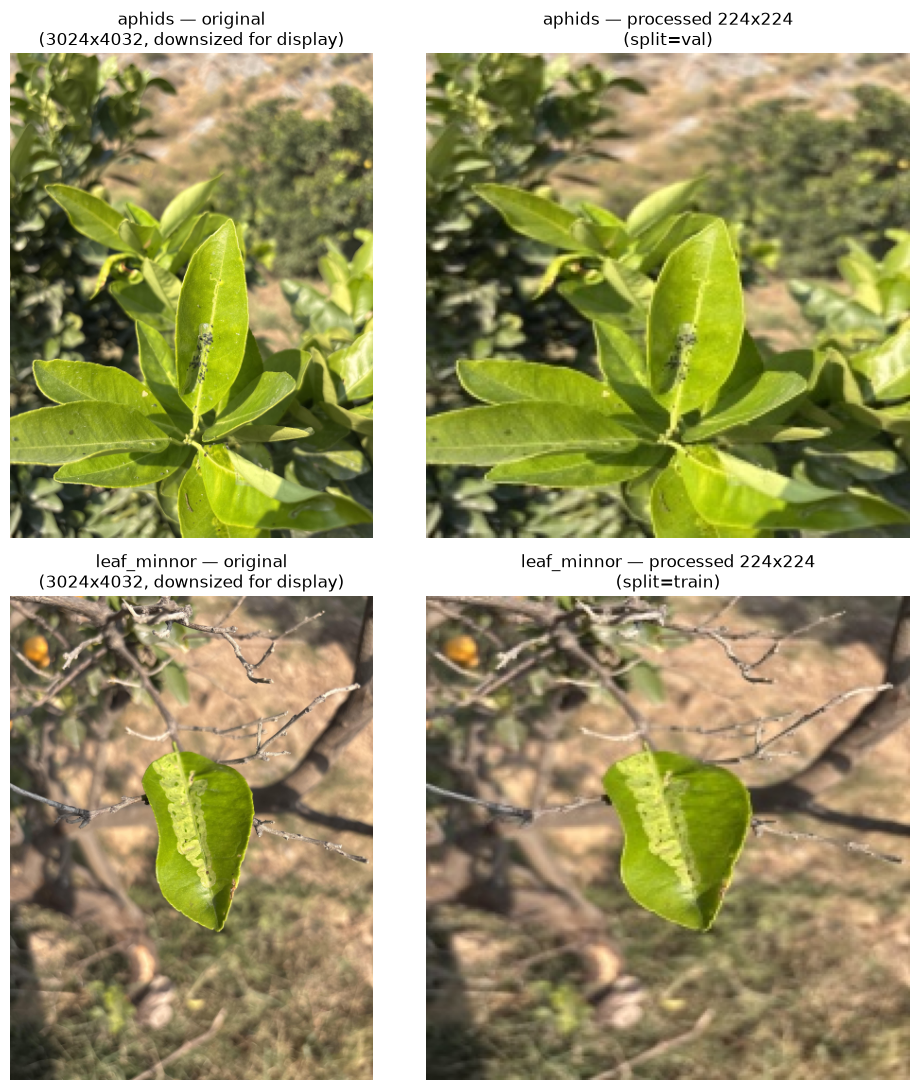

In [11]:
rng = random.Random(RANDOM_SEED)
chosen_classes = rng.sample(sorted(df["class_label"].unique()), 2)

sample_rows = [
    df[df["class_label"] == cls].sample(1, random_state=RANDOM_SEED).iloc[0]
    for cls in chosen_classes
]

fig, axes = plt.subplots(2, 2, figsize=(10, 11))

for i, row in enumerate(sample_rows):
    orig_bgr = cv2.imread(row["filepath"], cv2.IMREAD_COLOR)
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    h, w = orig_rgb.shape[:2]

    # downsize just for display (keep aspect ratio, cap longest side at 512px)
    scale = 512 / max(h, w)
    display_orig = cv2.resize(orig_rgb, (int(w * scale), int(h * scale)),
                               interpolation=cv2.INTER_AREA)

    processed_path = PROCESSED_ROOT / "224" / row["split"] / row["class_label"] / Path(row["filepath"]).name
    proc_bgr = cv2.imread(str(processed_path), cv2.IMREAD_COLOR)
    proc_rgb = cv2.cvtColor(proc_bgr, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(display_orig)
    axes[i, 0].set_title(f"{row['class_label']} — original\n({w}x{h}, downsized for display)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(proc_rgb)
    axes[i, 1].set_title(f"{row['class_label']} — processed 224x224\n(split={row['split']})")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()